# Project Title : Telco Customer Churn Prediction using Decision Tree


## Objective
The goal of this project is to predict whether a customer will leave
(Churn = Yes) or stay (Churn = No) using a Decision Tree Classifier.

We will:
1. Explore and preprocess the dataset
2. Build an unconstrained baseline Decision Tree
3. Compare Gini and Entropy criteria
4. Tune hyperparameters using GridSearchCV
5. Apply Cost Complexity Pruning
6. Analyze feature importance
7. Visualize the final pruned tree
8. Trace one customer's decision path
9. Compare decision boundaries of unpruned and pruned trees

# PART 1 — Import Libraries

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV # We will use gridsearchCV for hyperparameter tuning
from sklearn.tree import (
    DecisionTreeClassifier, plot_tree, export_text #We will use DecisionTreeClassifier as our ML Algorith
)
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')
print(" Imported libraries successfully")

 Imported libraries successfully


# PART 2 — Load Dataset

In [45]:
#Upload Dataset

from google.colab import files

uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn (1).csv


In [46]:
#Read Dataset

import io

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 21)


# PART 3 — Initial EDA

In [47]:
#First 5 Rows

df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##Explanation

### Initial Observation

The dataset contains customer-level information such as:

- Gender
- Senior Citizen
- Partner
- Dependents
- Tenure
- Phone Service
- Internet Service
- Contract
- Payment Method
- Monthly Charges
- Total Charges

The target variable is `Churn`.

In [48]:
#Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


We should look at the "TotalCharges" It is often stored as object instead of numeric because it contains blank strings.

In [49]:
#Statistical Summary

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
#Check Missing Values

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


##However, there is an important problem.

TotalCharges may contain blank strings " " instead of actual NaN values.

So we need to fix that.

# PART 4 — Data Cleaning

In [51]:
#Data Cleaning

print("Blank TotalCharges:",
      (df['TotalCharges'].astype(str).str.strip() == '').sum())

Blank TotalCharges: 11


In [52]:
#Convert TotalCharges to Numeric

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'    #If Python finds something that cannot be converted into a number, 'coerce' converts it to 'NaN. Black strings in to missing values.
)

In [53]:
#Check Missing Values Again

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# Now 11 missing values are appearing under: 'TotalCharges'

In [56]:
#Handle Missing Values

df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


# PART 5 — Remove Customer ID

customerID is just an identifier. It does not provide meaningful information for predicting churn.

In [57]:
df = df.drop('customerID', axis=1)

print(df.shape)

(7043, 20)


# PART 6 — Explore Target Variable

In [58]:
print(df['Churn'].value_counts)

print("n/percentage")
print(df['Churn'].value_counts(normalize=True)*100)

<bound method IndexOpsMixin.value_counts of 0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: object>
n/percentage
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


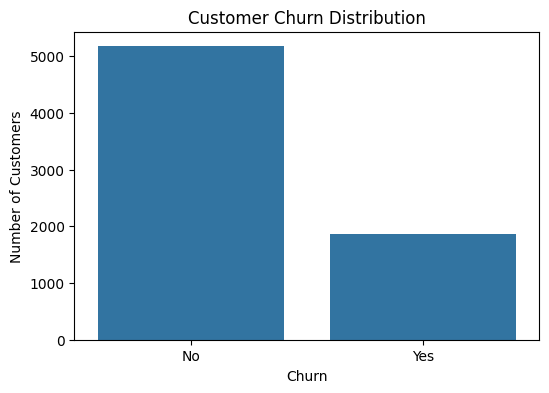

In [59]:
#Plot Churn

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()


##Explanation

### Observation

The target variable is imbalanced.

There are more customers who stayed (`No`) than customers who churned (`Yes`).

Therefore, a stratified train-test split is important so that both
training and testing datasets maintain approximately the same
Churn distribution.

# PART 7 — Explore Important Features

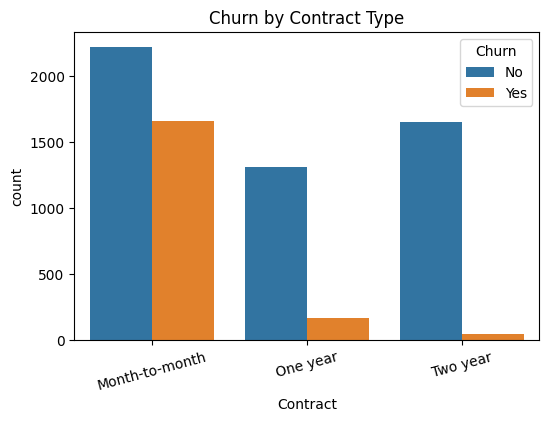

In [61]:
#Churn vs Contract

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.xticks(rotation = 15)

plt.show()

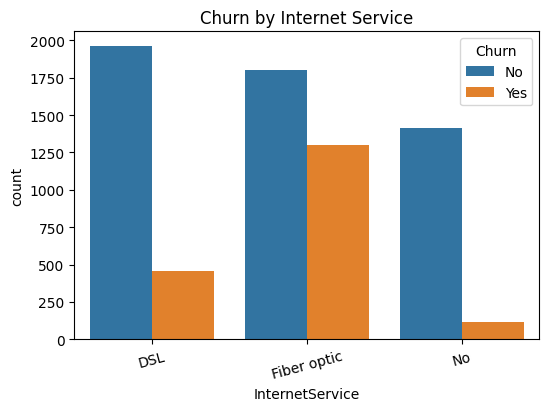

In [62]:
#Churn vs Internet Service

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service')
plt.xticks(rotation = 15)

plt.show()

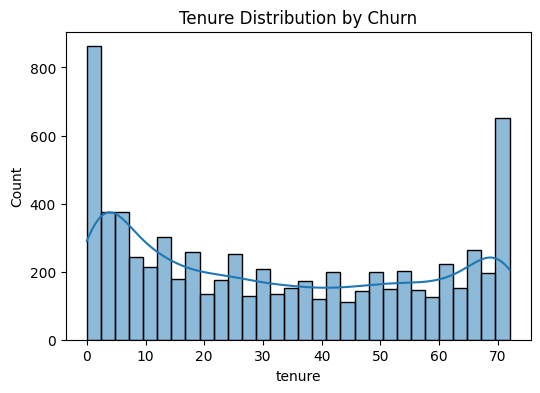

In [63]:
#Tenure Distribution

plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='tenure', bins=30, kde ='True')
plt.title('Tenure Distribution by Churn')

plt.show()

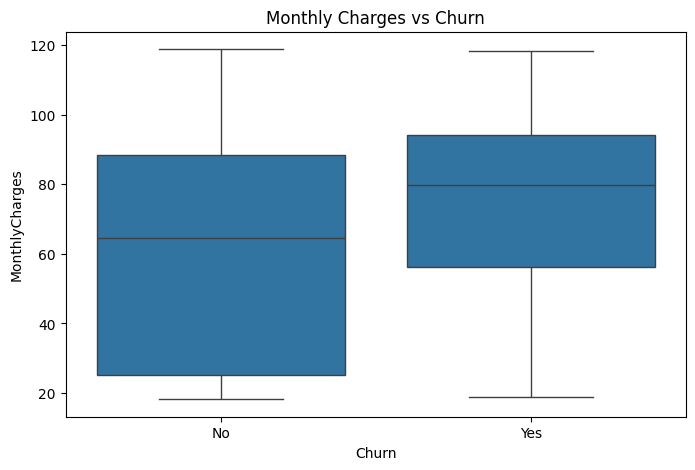

In [65]:
#Monthly Charges

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges vs Churn')

plt.show()


### EDA Observation

Some variables appear to have a strong relationship with churn.

In particular:

- Contract type
- Tenure
- Monthly Charges
- Internet Service

appear potentially useful for predicting customer churn.

However, we will allow the Decision Tree model to determine feature
importance rather than assuming these variables are the strongest.

# PART 8 — Encode Categorical Variables

##Our Decision Tree needs numerical inputs.

Currently we have values such as:

Yes / No
Month-to-month / One year / Two year
DSL / Fiber optic / No

We need to convert these into numbers.

In [72]:
#Separate X and y

X = df.drop('Churn', axis=1)
y = df['Churn']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 19)
Target: (7043,)


In [73]:
#One-Hot Encoding (Easiest approach to convert in to numeric)

X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

print("Encoded feature shape:", X_encoded.shape)

Encoded feature shape: (7043, 30)


In [74]:
#Convert Target

y = y.map({
    'No': 0,
    'Yes': 1
})

print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


# PART 9 — Stratified Train/Test Split

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5634, 30)
Testing set: (1409, 30)


## stratify=y?

Because the dataset is imbalanced.

Stratifing the 'y' ensures that the percentage of churners in the training and testing datasets remains approximately the same as the original dataset.

## PART 10 — Baseline Decision Tree

Now we build the deliberately unconstrained tree.

This is important because it demonstrates overfitting.

In [76]:
baseline_tree = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

baseline_tree.fit(X_train, y_train)

print("Baseline tree trained!")

Baseline tree trained!


## we did not specify:

max_depth,
min_samples_split,
min_samples_leaf,
ccp_alpha

Therefore, the tree is allowed to grow very deep.

In [77]:
#Baseline Performance

train_pred = baseline_tree.predict(X_train)
test_pred = baseline_tree.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)
print("Tree Depth:", baseline_tree.get_depth())

Training Accuracy: 0.9980475683351083
Testing Accuracy : 0.7416607523066004
Tree Depth: 24


In [78]:
#Show Overfitting

print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy :", round(test_accuracy, 4))

print("\nAccuracy Gap:",
      round(train_accuracy - test_accuracy, 4))

Training Accuracy: 0.998
Testing Accuracy : 0.7417

Accuracy Gap: 0.2564


### Baseline Model Observation

The unconstrained Decision Tree achieves very high training accuracy
but considerably lower testing accuracy.

This indicates overfitting.

The tree has learned many very specific patterns from the training data
that do not generalize well to unseen customers.

Therefore, we need to control the complexity of the tree.

# PART 11 — Confusion Matrix

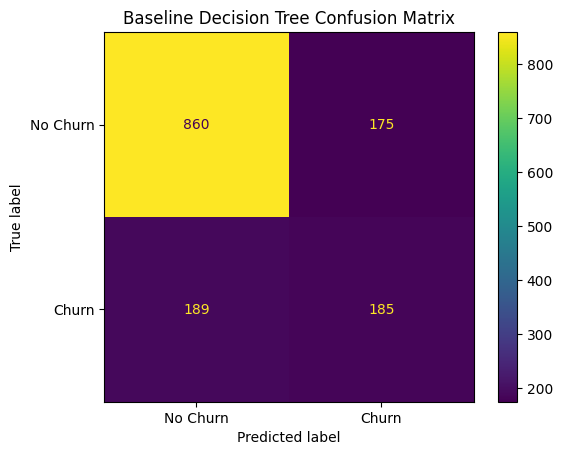

In [79]:
cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot()

plt.title('Baseline Decision Tree Confusion Matrix')
plt.show()

# PART 12 — Classification Report

In [80]:
print(
    classification_report(
        y_test,
        test_pred,
        target_names=['No Churn', 'Churn']
    )
)

              precision    recall  f1-score   support

    No Churn       0.82      0.83      0.83      1035
       Churn       0.51      0.49      0.50       374

    accuracy                           0.74      1409
   macro avg       0.67      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409



# PART 13 — Gini vs Entropy

In [83]:
#Gini Model

gini_tree = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

gini_tree.fit(X_train, y_train)

gini_train_acc = accuracy_score(
    y_train,
    gini_tree.predict(X_train)
)

gini_test_acc = accuracy_score(
    y_test,
    gini_tree.predict(X_test)
)

In [84]:
#Entropy Model

entropy_tree = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

entropy_tree.fit(X_train, y_train)

entropy_train_acc = accuracy_score(
    y_train,
    entropy_tree.predict(X_train)
)

entropy_test_acc = accuracy_score(
    y_test,
    entropy_tree.predict(X_test)
)

In [85]:
# Compare : Gini Vs Entropy

comparison = pd.DataFrame({
    'Criterion': ['Gini', 'Entropy'],
    'Train Accuracy': [
        gini_train_acc,
        entropy_train_acc
    ],
    'Test Accuracy': [
        gini_test_acc,
        entropy_test_acc
    ],
    'Tree Depth': [
        gini_tree.get_depth(),
        entropy_tree.get_depth()
    ],
    'Number of Leaves': [
        gini_tree.get_n_leaves(),
        entropy_tree.get_n_leaves()
    ]
})

comparison

,Criterion,Train Accuracy,Test Accuracy,Tree Depth,Number of Leaves
0,Gini,0.998048,0.741661,24,1098
1,Entropy,0.998048,0.730305,31,1059


# PART 14 — First Feature Selected

The root node is the first feature used by the tree.

In [86]:
gini_root_index = gini_tree.tree_.feature[0]
entropy_root_index = entropy_tree.tree_.feature[0]

gini_root_feature = X_train.columns[gini_root_index]
entropy_root_feature = X_train.columns[entropy_root_index]

print("Gini first feature:", gini_root_feature)
print("Entropy first feature:", entropy_root_feature)

Gini first feature: tenure
Entropy first feature: Contract_Two year


### Gini vs Entropy

Gini impurity and entropy are both measures of node impurity.

- Gini measures how mixed the classes are.
- Entropy measures the uncertainty/information content.

Both criteria usually produce similar but not necessarily identical
Decision Trees.

The exact root feature and tree structure may differ.

# PART 15 — Hyperparameter Tuning

Now we find a better tree automatically.

We were asked to search:

max_depth:
[3, 5, 7, 10, None]

min_samples_split:
[2, 10, 20, 50]

min_samples_leaf:
[1, 5, 10, 20]

criterion:
[gini, entropy]

In [87]:
#GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Grid search completed!")

Grid search completed!


In [88]:
#Best Parameters

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 20, 'min_samples_split': 2}

Best Cross-Validation Accuracy:
0.790022080343451


In [89]:
#Best Model

best_tree = grid_search.best_estimator_

best_train_pred = best_tree.predict(X_train)
best_test_pred = best_tree.predict(X_test)

best_train_acc = accuracy_score(
    y_train,
    best_train_pred
)

best_test_acc = accuracy_score(
    y_test,
    best_test_pred
)

print("Best Model Training Accuracy:", best_train_acc)
print("Best Model Testing Accuracy :", best_test_acc)
print("Tree Depth:", best_tree.get_depth())
print("Number of Leaves:", best_tree.get_n_leaves())

Best Model Training Accuracy: 0.8077742279020235
Best Model Testing Accuracy : 0.8019872249822569
Tree Depth: 7
Number of Leaves: 66


# PART 16 — Compare Baseline vs Tuned Model

In [90]:
model_comparison = pd.DataFrame({
    'Model': [
        'Baseline Tree',
        'Tuned Tree'
    ],
    'Train Accuracy': [
        train_accuracy,
        best_train_acc
    ],
    'Test Accuracy': [
        test_accuracy,
        best_test_acc
    ],
    'Tree Depth': [
        baseline_tree.get_depth(),
        best_tree.get_depth()
    ]
})

model_comparison

,Model,Train Accuracy,Test Accuracy,Tree Depth
0,Baseline Tree,0.998048,0.741661,24
1,Tuned Tree,0.807774,0.801987,7


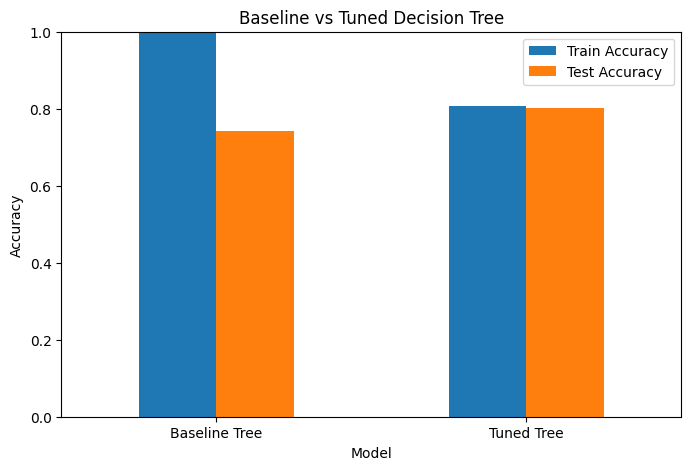

In [91]:
#Plot Comparison

model_comparison.set_index('Model')[
    ['Train Accuracy', 'Test Accuracy']
].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Baseline vs Tuned Decision Tree')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

## The tuned model generally have:

-lower training accuracy than the unconstrained tree

-better generalization

-smaller tree

-smaller train-test accuracy gap

# That is exactly what we want.

# PART 17 — Cost Complexity Pruning

This is the more advanced part of our project.

We will use  'cost_complexity_pruning_path()' to find the value of 'ccp_alpha'

In [93]:
#Get Alpha Values

path = baseline_tree.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

print("Number of candidate alpha values:", len(ccp_alphas))

Number of candidate alpha values: 445


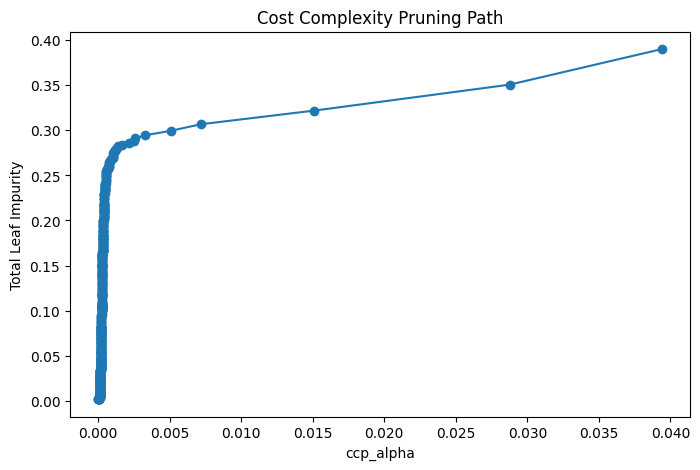

In [94]:
#Plot Alpha vs Impurity

plt.figure(figsize=(8,5))

plt.plot(
    ccp_alphas,
    impurities,
    marker='o'
)

plt.xlabel('ccp_alpha')
plt.ylabel('Total Leaf Impurity')
plt.title('Cost Complexity Pruning Path')

plt.show()

# PART 18 — Train Trees for Different Alpha Values

In [95]:
pruned_trees = []

for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(
        criterion='gini',
        ccp_alpha=alpha,
        random_state=42
    )

    tree.fit(X_train, y_train)

    pruned_trees.append(tree)

print("Trees trained:", len(pruned_trees))

Trees trained: 445


# PART 19 — Accuracy vs Alpha

In [127]:
train_scores = [
    accuracy_score(y_train, tree.predict(X_train))
    for tree in pruned_trees
]

test_scores = [
    accuracy_score(y_test, tree.predict(X_test))
    for tree in pruned_trees
]

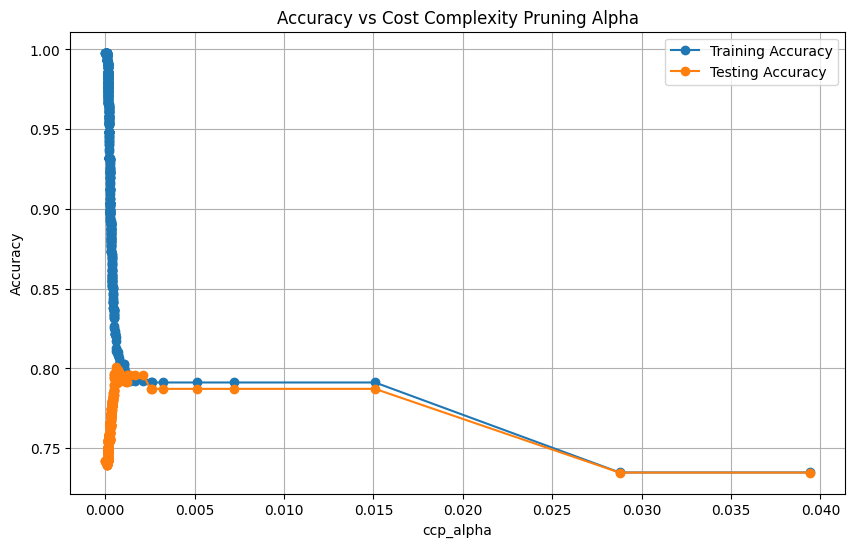

In [97]:
#Plot

plt.figure(figsize=(10,6))

plt.plot(
    ccp_alphas,
    train_scores,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    ccp_alphas,
    test_scores,
    marker='o',
    label='Testing Accuracy'
)

plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Cost Complexity Pruning Alpha')

plt.legend()
plt.grid(True)

plt.show()

# We want an alpha where:

Test accuracy is high

while

Training accuracy is not excessively higher than test accuracy.

# PART 20 — Find Best Pruned Alpha

In [98]:
best_alpha_index = np.argmax(test_scores)

best_alpha = ccp_alphas[best_alpha_index]

print("Best ccp_alpha:", best_alpha)
print("Best Test Accuracy:", test_scores[best_alpha_index])

Best ccp_alpha: 0.0005761197463884926
Best Test Accuracy: 0.8005677785663591


# PART 21 — Train Final Pruned Tree

In [99]:
pruned_tree = DecisionTreeClassifier(
    criterion='gini',
    ccp_alpha=best_alpha,
    random_state=42
)

pruned_tree.fit(X_train, y_train)

pruned_train_pred = pruned_tree.predict(X_train)
pruned_test_pred = pruned_tree.predict(X_test)

pruned_train_acc = accuracy_score(
    y_train,
    pruned_train_pred
)

pruned_test_acc = accuracy_score(
    y_test,
    pruned_test_pred
)

print("Pruned Tree")
print("----------------")
print("Alpha:", best_alpha)
print("Train Accuracy:", pruned_train_acc)
print("Test Accuracy:", pruned_test_acc)
print("Depth:", pruned_tree.get_depth())
print("Leaves:", pruned_tree.get_n_leaves())

Pruned Tree
----------------
Alpha: 0.0005761197463884926
Train Accuracy: 0.8173588924387647
Test Accuracy: 0.8005677785663591
Depth: 9
Leaves: 42


# PART 22 — Compare All Main Models

In [100]:
final_comparison = pd.DataFrame({
    'Model': [
        'Baseline Gini',
        'Baseline Entropy',
        'GridSearch Best',
        'Pruned Tree'
    ],

    'Train Accuracy': [
        gini_train_acc,
        entropy_train_acc,
        best_train_acc,
        pruned_train_acc
    ],

    'Test Accuracy': [
        gini_test_acc,
        entropy_test_acc,
        best_test_acc,
        pruned_test_acc
    ],

    'Depth': [
        gini_tree.get_depth(),
        entropy_tree.get_depth(),
        best_tree.get_depth(),
        pruned_tree.get_depth()
    ],

    'Leaves': [
        gini_tree.get_n_leaves(),
        entropy_tree.get_n_leaves(),
        best_tree.get_n_leaves(),
        pruned_tree.get_n_leaves()
    ]
})

final_comparison

,Model,Train Accuracy,Test Accuracy,Depth,Leaves
0,Baseline Gini,0.998048,0.741661,24,1098
1,Baseline Entropy,0.998048,0.730305,31,1059
2,GridSearch Best,0.807774,0.801987,7,66
3,Pruned Tree,0.817359,0.800568,9,42


# PART 23 — Feature Importance

Now we identify which features the final tree considers most useful.

In [101]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': pruned_tree.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

importance_df.head(10)

,Feature,Importance
1,tenure,0.381745
10,InternetService_Fiber optic,0.323869
3,TotalCharges,0.069597
2,MonthlyCharges,0.033690
28,PaymentMethod_Electronic check,0.032919
25,Contract_Two year,0.023740
9,MultipleLines_Yes,0.021405
12,OnlineSecurity_No internet service,0.018722
19,TechSupport_Yes,0.017892
16,DeviceProtection_No internet service,0.015742


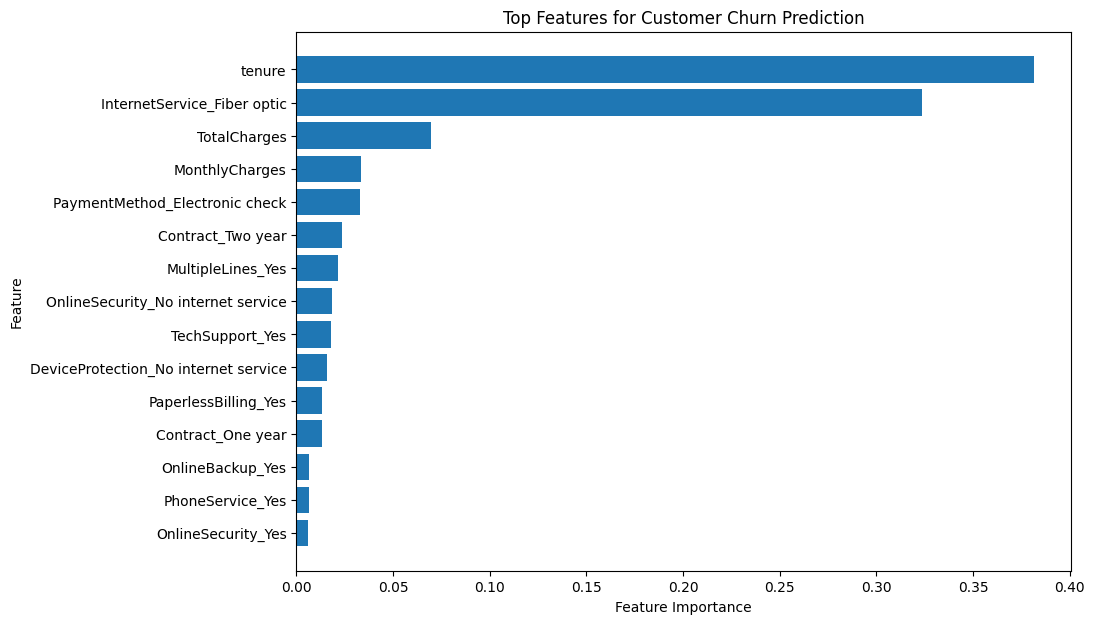

In [102]:
#Feature Importance Plot

top_features = importance_df.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top Features for Customer Churn Prediction')

plt.show()

In [104]:
#Top 5 Churn Drivers

print("Top 5 Features:")
print(importance_df.head(5))

Top 5 Features:
                           Feature  Importance
1                           tenure    0.381745
10     InternetService_Fiber optic    0.323869
3                     TotalCharges    0.069597
2                   MonthlyCharges    0.033690
28  PaymentMethod_Electronic check    0.032919


# PART 24 — Visualize the Pruned Tree

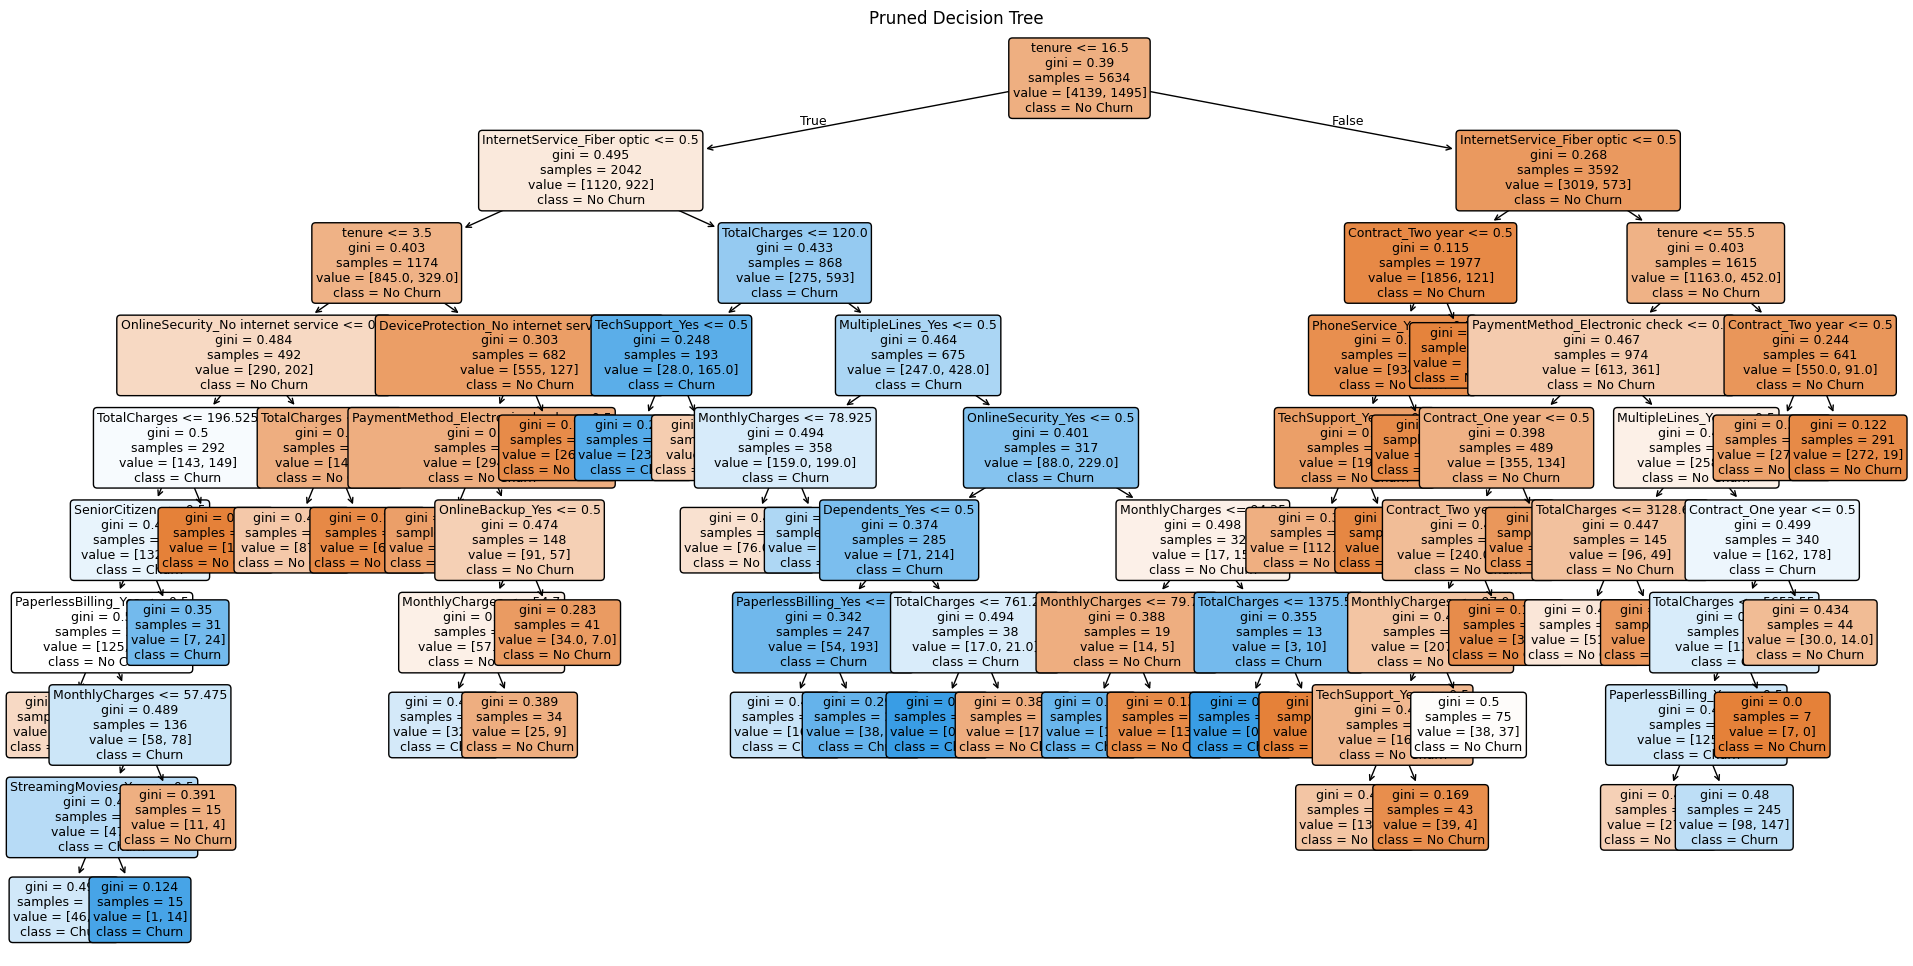

In [105]:
plt.figure(figsize=(24,12))

plot_tree(
    pruned_tree,
    feature_names=X_train.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title('Pruned Decision Tree')

plt.show()

# If the tree is still large, we can visualize only the first few levels:

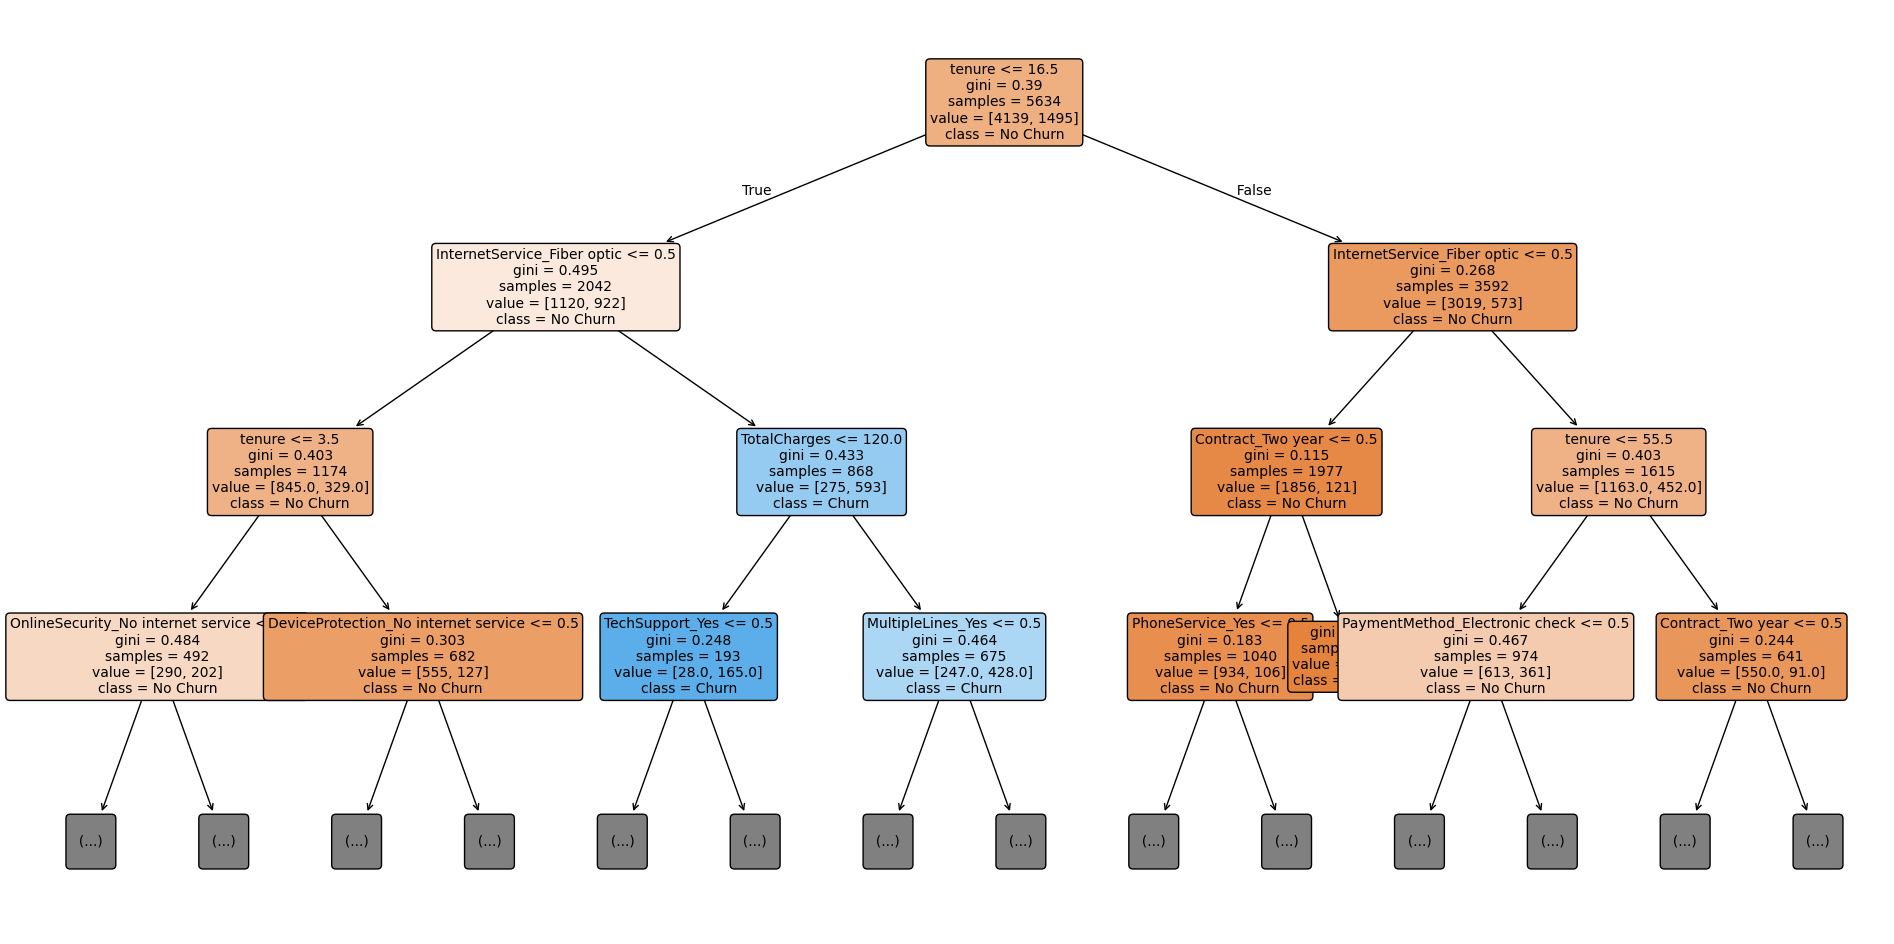

In [106]:
plt.figure(figsize=(24,12))

plot_tree(
    pruned_tree,
    feature_names=X_train.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)

plt.show()

# PART 25 — Trace One Customer

In [107]:
customer_index = X_test.index[0]

customer = X_test.loc[[customer_index]]

actual = y_test.loc[customer_index]

prediction = pruned_tree.predict(customer)[0]

print("Customer index:", customer_index)
print("Actual:", "Churn" if actual == 1 else "No Churn")
print("Predicted:", "Churn" if prediction == 1 else "No Churn")

Customer index: 437
Actual: No Churn
Predicted: No Churn


# PART 26 — Trace the Decision Path

In [115]:
node_indicator = pruned_tree.decision_path(customer)

leaf_id = pruned_tree.apply(customer)

feature = pruned_tree.tree_.feature
threshold = pruned_tree.tree_.threshold

print("Decision path:\n")

for node_id in node_indicator.indices:

    if leaf_id[0] == node_id:
        continue

    feature_name = X_train.columns[feature[node_id]]
    threshold_value = threshold[node_id]
    customer_value = customer.iloc[0][feature_name]

    if customer_value <= threshold_value:
        decision = "<="
    else:
        decision = ">"

    print(
        f"{feature_name} = {customer_value:.2f} "
        f"{decision} {threshold_value:.2f}"
    )

Decision path:

tenure = 72.00 > 16.50
InternetService_Fiber optic = 1.00 > 0.50
tenure = 72.00 > 55.50
Contract_Two year = 1.00 > 0.50


### Customer Decision Explanation

The Decision Tree makes its prediction by passing the customer through
a sequence of questions.

For example:

1. Is the customer's tenure <= a certain value?
2. Is the monthly charge > a certain value?
3. Is the contract type month-to-month?
4. Continue through the tree until a leaf node is reached.

The final leaf contains the model's prediction.

This makes Decision Trees relatively easy to interpret compared with
many other machine learning models.

# PART 27 — Bonus: 2D Decision Boundary
This is an excellent visual demonstration of overfitting.
We will use:

tenure

MonthlyCharges

Our full model contains many features. To make a 2D decision boundary, we need to train separate trees using only these two features.

In [116]:
#Prepare Two Features

two_features = ['tenure', 'MonthlyCharges']

X_2d = df[two_features]
y_2d = y

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d,
    y_2d,
    test_size=0.20,
    random_state=42,
    stratify=y_2d
)

print(X2_train.shape)
print(X2_test.shape)

(5634, 2)
(1409, 2)


In [117]:
#Unpruned 2D Tree

tree_2d_unpruned = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

tree_2d_unpruned.fit(
    X2_train,
    y2_train
)

DecisionTreeClassifier(random_state=42)

In [118]:
#Pruned 2D Tree

tree_2d_pruned = DecisionTreeClassifier(
    criterion='gini',
    ccp_alpha=best_alpha,
    random_state=42
)

tree_2d_pruned.fit(
    X2_train,
    y2_train
)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0005761197463884926),
                       random_state=42)

In [123]:
#Decision Boundary Function

def plot_decision_boundary(model, X, y, title):

    x_min = X['tenure'].min() - 1
    x_max = X['tenure'].max() + 1

    y_min = X['MonthlyCharges'].min() - 5
    y_max = X['MonthlyCharges'].max() + 5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = pd.DataFrame({
        'tenure': xx.ravel(),
        'MonthlyCharges': yy.ravel()
    })

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(9,6))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.25
    )

    plt.scatter(
        X['tenure'],
        X['MonthlyCharges'],
        c=y,
        edgecolor='k',
        alpha=0.6
    )

    plt.xlabel('Tenure')
    plt.ylabel('Monthly Charges')
    plt.title(title)

    plt.show()

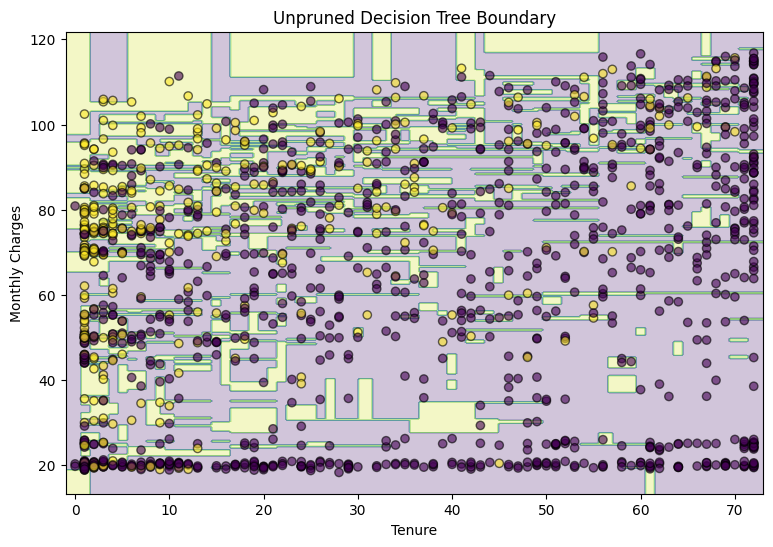

In [122]:
#Unpruned Boundary

plot_decision_boundary(
    tree_2d_unpruned,
    X2_test,
    y2_test,
    'Unpruned Decision Tree Boundary'
)

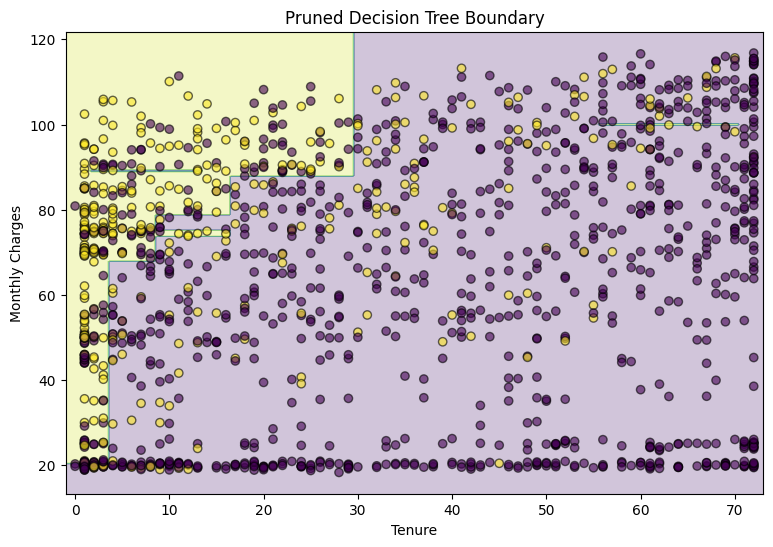

In [124]:
#Pruned Boundary

plot_decision_boundary(
    tree_2d_pruned,
    X2_test,
    y2_test,
    'Pruned Decision Tree Boundary'
)

### Bonus Observation

The unpruned tree tends to create a more complicated and fragmented
decision boundary.

This happens because the tree tries to fit individual training
observations, including noise and unusual cases.

The pruned tree produces a simpler decision boundary.

This demonstrates visually why pruning can improve generalization.

# PART 28 — Final Model Evaluation

In [125]:
print("FINAL PRUNED MODEL")
print("==================")

print("Accuracy:",
      round(pruned_test_acc, 4))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        pruned_test_pred,
        target_names=['No Churn', 'Churn']
    )
)

FINAL PRUNED MODEL
Accuracy: 0.8006

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



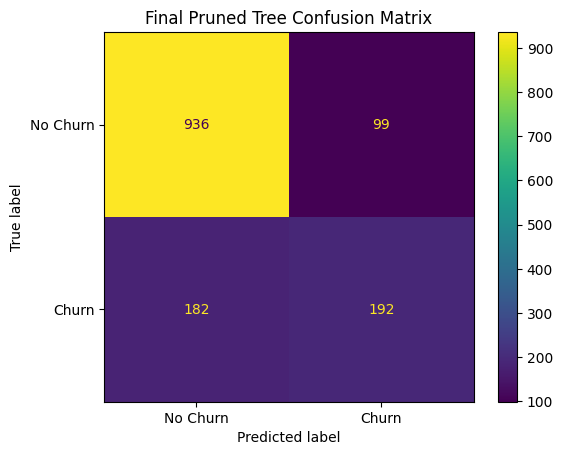

In [126]:
#Final Confusion Matrix

cm = confusion_matrix(
    y_test,
    pruned_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot()

plt.title('Final Pruned Tree Confusion Matrix')

plt.show()

# PART-29- Final Conclusion


# Final Conclusion

This project used a Decision Tree Classifier to predict customer churn
using the Telco Customer Churn dataset.

The analysis started with exploratory data analysis and preprocessing.
The `TotalCharges` column contained blank strings, which were converted
to missing values and then handled using median imputation.

Categorical variables were converted into numerical features using
one-hot encoding. A stratified train-test split was used because the
target variable was imbalanced.

An unconstrained baseline Decision Tree achieved very high training
accuracy but substantially lower testing accuracy. This demonstrated
clear overfitting.

Gini and Entropy criteria were then compared. Both produced similar
results, although the exact tree structure and first splitting feature
could differ.

GridSearchCV was used to find better values for:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Cost Complexity Pruning was also applied using `ccp_alpha`. The
pruning process reduced unnecessary tree branches and produced a
simpler model with better generalization.

Feature importance analysis showed which customer characteristics were
most useful for predicting churn. Features related to contract,
tenure, monthly charges and internet/service characteristics were
among the important predictors, although the exact ranking depends on
the fitted model.

Finally, the decision boundary experiment showed that the unpruned
tree creates a more complex boundary, while the pruned tree creates a
simpler boundary. This provides a visual explanation of overfitting
and why controlling model complexity is important.